In [53]:
pip install pipes_vis

Note: you may need to restart the kernel to use updated packages.


In [54]:
# https://github.com/HinLeung622/pipes_vis/blob/main/pipes_vis_example.ipynb
import pipes_vis as v
import numpy as np
import pandas as pd

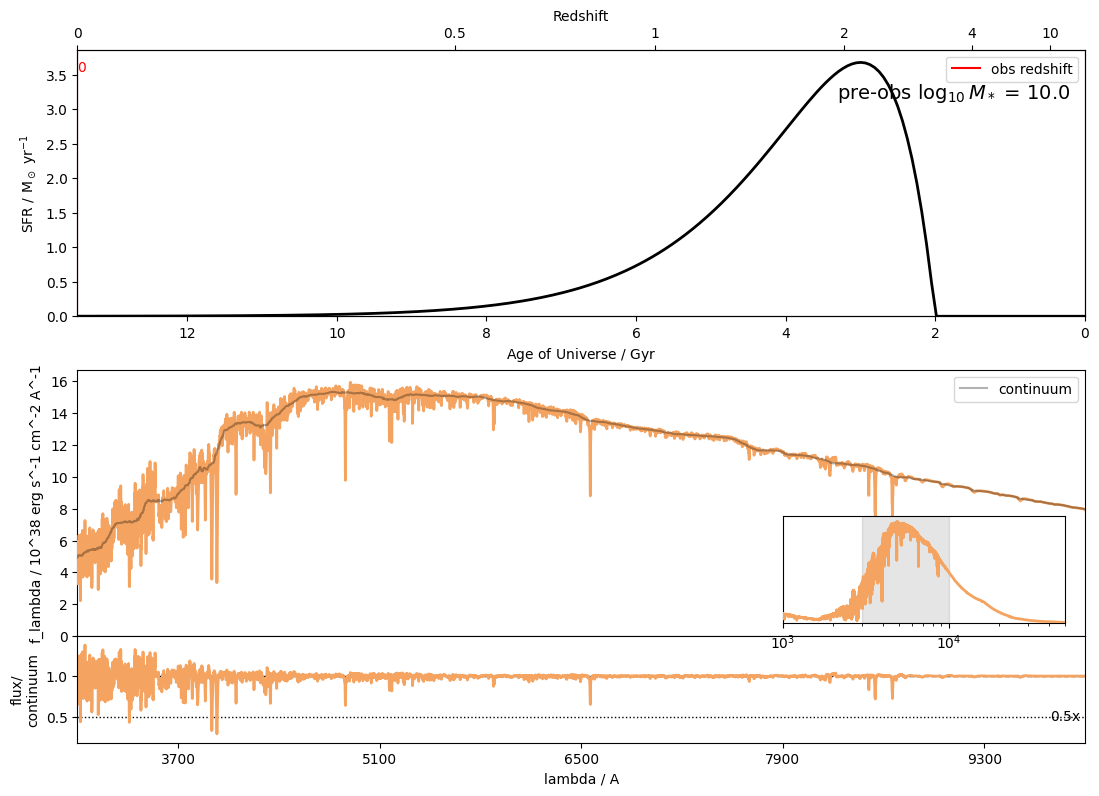

In [55]:
delayed = {}
delayed["massformed"] = 10.0                 # total log_10(M*/M_sun) of the galaxy, for the whole SFH
delayed["metallicity"] = 0.1                 # assumed constant metallicity, in number of times of Z_sun
delayed["tform"] = 2                        # age of universe when the population formed, Gyr
delayed["tau"] = 1                          # SFR decay timescale of the population, Gyr

dust = {}                                    # dust attenuation and emission, implementation identical to bagpipes
dust["type"] = "CF00"                        # Charlot & Fall (2001)
dust["eta"] = 2.0                            # additional scaling factor for dust in birth clouds (1/mu)
dust["Av"] = 0                               # extinction in V band (5500AA)
dust["n"] = 0.7                              # slope of the attenuation law


init_components = {}

init_components["redshift"] = 0          # redshift at observation
init_components["delayed"] = delayed
init_components["spec_lim"] = [3000,10000]   # wavelength boundaries of the main spectrum panel
init_components["dust"] = dust

simple_vis = v.visualizer(init_components)
simple_vis.static_plot()
spectrum=simple_vis.model.spectrum

(3000.0, 10000.0)

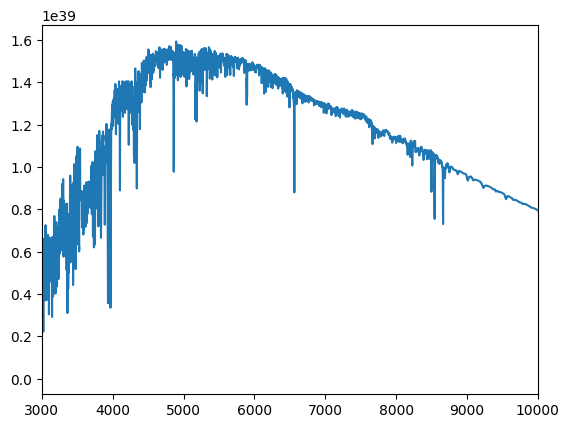

In [56]:
import matplotlib.pyplot as plt
plt.plot(spectrum[:,0],spectrum[:,1])
plt.xlim(3000,10000)

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import copy

In [58]:
def make_sed(massformed=10.0, metallicity=0.1, tform=2.0, tau=1.0,
             Av=0.0, n=0.7, eta=2.0, redshift=0):

    delayed = {
        "massformed": massformed,
        "metallicity": metallicity,
        "tform": tform,
        "tau": tau
    }

    dust = {
        "type": "CF00",
        "eta": eta,
        "Av": Av,
        "n": n
    }

    components = {
        "redshift": redshift,
        "delayed": delayed,
        "spec_lim": [3000, 10000],
        "dust": dust
    }

    vis = v.visualizer(components)


    vis.static_plot()
    plt.close()

    return vis.model.spectrum

In [59]:
import numpy as np
import bagpipes as pipes

def make_sed_fast(massformed=10.0, metallicity=0.1, tform=2.0, tau=1.0,
                  Av=0.0, n=0.7, eta=2.0, redshift=0.0):

    age_of_universe = 13.8  # Gyr, rough low-redshift approximation
    age = age_of_universe - tform

    components = {
        "redshift": redshift,
        "delayed": {
            "massformed": massformed,
            "metallicity": metallicity,
            "age": age,
            "tau": tau
        },
        "dust": {
            "type": "CF00",
            "eta": eta,
            "Av": Av,
            "n": n
        }
    }

    wavs = np.arange(3000.0, 10000.0, 5.0)

    model = pipes.model_galaxy(
        components,
        spec_wavs=wavs
    )

    return model.spectrum

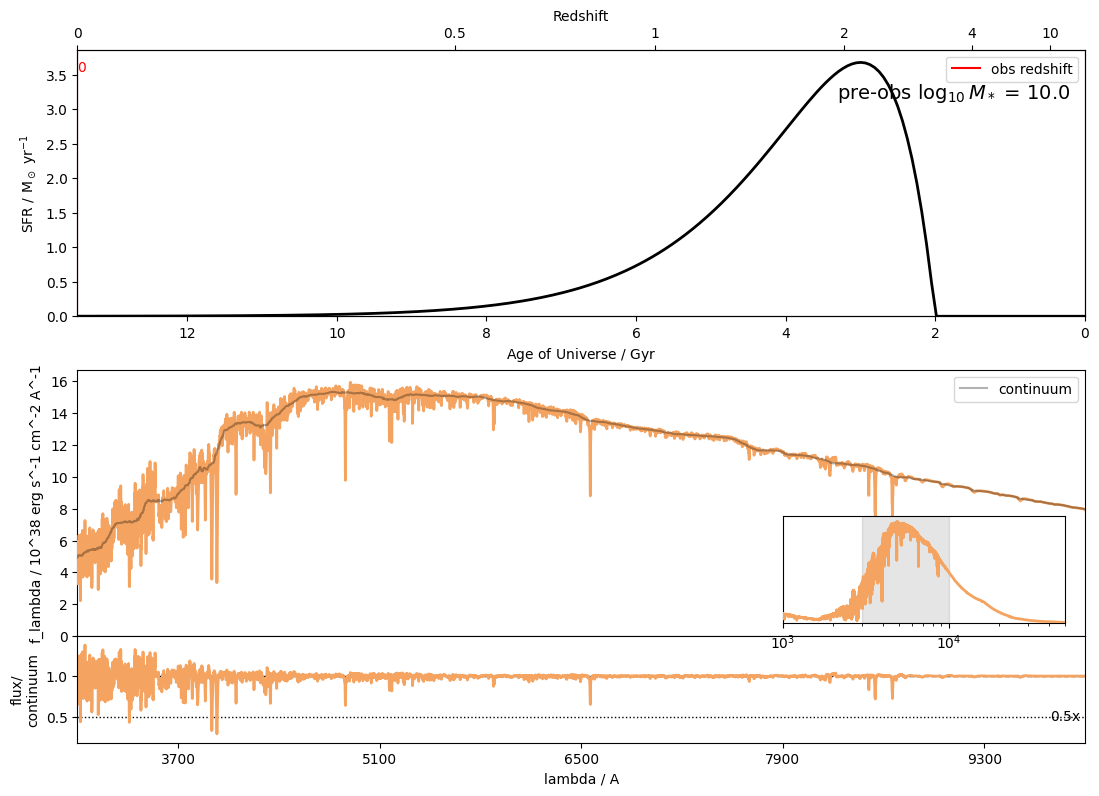

In [60]:
baseline_params = {
    "massformed": 10.0,
    "metallicity": 0.1,
    "tform": 2.0,
    "tau": 1.0,
    "Av": 0.0,
    "n": 0.7,
    "eta": 2.0
}

baseline_sed = make_sed(**baseline_params)

In [61]:
def normalise_sed(sed):
    wave = sed[:, 0]
    flux = sed[:, 1]
    flux_norm = flux / np.nanmedian(flux)
    return wave, flux_norm


def sed_distance(sed1, sed2, wave_min=3000, wave_max=10000):
    w1, f1 = normalise_sed(sed1)
    w2, f2 = normalise_sed(sed2)

    f2_interp = np.interp(w1, w2, f2)

    mask = (w1 >= wave_min) & (w1 <= wave_max)

    diff = f1[mask] - f2_interp[mask]

    chi2_like = np.nanmean(diff**2)
    max_abs_diff = np.nanmax(np.abs(diff))

    return chi2_like, max_abs_diff

In [62]:
test_sed = make_sed_fast(
    massformed=10.0,
    metallicity=0.1,
    tform=2.0,
    tau=1.0,
    Av=0.0,
    n=0.7,
    eta=2.0
)

print(test_sed.shape)
print(test_sed[:5])

(1400, 2)
[[3.00000000e+03 4.09217315e+38]
 [3.00500000e+03 4.66075611e+38]
 [3.01000000e+03 4.80629958e+38]
 [3.01500000e+03 5.04104907e+38]
 [3.02000000e+03 3.50175091e+38]]


In [63]:
grid = {
    "massformed": [10.0],
    "metallicity": [0.03, 0.05, 0.1, 0.2, 0.4],
    "tform": [1.0, 1.5, 2.0, 2.5, 3.0],
    "tau": [0.3, 0.5, 1.0, 1.5, 2.0, 3.0],
    "Av": [0.0, 0.05, 0.1, 0.15, 0.2, 0.3],
    "n": [0.5, 0.7, 0.9],
    "eta": [2.0]
}

results = []

keys = list(grid.keys())

for values in itertools.product(*[grid[k] for k in keys]):
    params = dict(zip(keys, values))

    # пропускаем сам baseline
    if all(np.isclose(params[k], baseline_params[k]) for k in baseline_params):
        continue

    try:
        sed = make_sed_fast(**params)
        chi2_like, max_abs_diff = sed_distance(baseline_sed, sed)

        results.append({
            **params,
            "chi2_like": chi2_like,
            "max_abs_diff": max_abs_diff,
            "sed": sed
        })

    except Exception as e:
        print("Failed:", params, e)

results_df = pd.DataFrame(results)
results_df = pd.DataFrame(results)

if len(results_df) == 0:
    raise RuntimeError("No successful models. Check the error messages printed above.")

results_df = results_df.sort_values("chi2_like").reset_index(drop=True)

results_df.head(10)

KeyboardInterrupt: 

In [ ]:
display(results_df.drop(columns=["sed"]).head(10))

In [ ]:
best = results_df.iloc[0]
best_sed = best["sed"]

w_base, f_base = normalise_sed(baseline_sed)
w_best, f_best = normalise_sed(best_sed)

plt.figure(figsize=(9, 5))
plt.plot(w_base, f_base, label="Baseline", linewidth=2)
plt.plot(w_best, f_best, "--", label="Best degenerate model", linewidth=2)

plt.xlabel("Wavelength [Å]")
plt.ylabel("Normalised flux")
plt.title("Baseline vs degenerate SED")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Best degenerate parameters:")
for k in ["massformed", "metallicity", "tform", "tau", "Av", "n", "eta"]:
    print(f"{k}: {best[k]}")

print("chi2_like:", best["chi2_like"])
print("max_abs_diff:", best["max_abs_diff"])